In [1]:
import numpy as np
from InfAdjFPFiniteDiffApp import InfAdjFPFiniteDiff_OriginalOperator
import matplotlib.pyplot as plt

In [2]:
dim = 2
mpl = 1.221e19
Pi = 100**0.5
M = 1e16 / mpl
phic = np.sqrt(2) * M
Lambda = 5.4e15 / mpl * (Pi / 10)**(-1) * M * phic**0.5
nWaterfall = 1
psirc = (nWaterfall * Lambda**4 * Pi / 48 / 2**0.5 / np.pi**1.5)**0.5
beta = 0.01

def infPotFunc(Phi):
    phi = Phi[0]
    psir = Phi[1]
    return float(Lambda**4 * ((1 - (psir / M)**2)**2 + 2 * (phi * psir / phic / M)**2 + beta * (phi - phic)**3))
    
def infPotDerivFunc_phi(Phi):
    phi = Phi[0]
    psir = Phi[1]
    return float(Lambda**4 * (4 * phi * (psir / phic / M)**2 + 3 * beta * (phi - phic)**2))
    
def infPotDerivFunc_psir(Phi):
    phi = Phi[0]
    psir = Phi[1]
    return float(Lambda**4 * (-4 * psir / M**2 * (1 - (psir / M)**2) + 4 * psir * (phi / phic / M)**2))

infPotentialDerivFuncs = [infPotDerivFunc_phi, infPotDerivFunc_psir]

nGrid = 64

In [3]:
phimax = 0.0011582421053083043
phimin = 0.0011582420263429574
psimax = 1.248173775679675e-16
psimin = -psimax

In [4]:
customGrid_phi = np.linspace(phimin, phimax, nGrid)
customGrid_psir = np.linspace(psimin, psimax, nGrid)

In [5]:
fpFinDiff_NeuNeu = InfAdjFPFiniteDiff_OriginalOperator(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    [nGrid, nGrid],
    [phimax, psimax],
    [phimin, -psimax],
    ["Neumann0", "Neumann0"],
    ["Neumann0", "Neumann0"],
    customGrid=[customGrid_phi, customGrid_psir]
)

# # ポテンシャルが一定以下ならインフレーション領域外として、当該点に対応する行列の要素を0とする
# customGrid_phi_woEnd = customGrid_phi[1:-1]
# customGrid_psir_woEnd = customGrid_psir[1:-1]
# vTh = (1 - 4.746948205088901201275e-16) * Lambda**4
# maskMat = np.full((len(customGrid_phi_woEnd), len(customGrid_psir_woEnd)), False)
# for i1 in range(len(customGrid_phi_woEnd)):
#     for i2 in range(len(customGrid_psir_woEnd)):
#         if infPotFunc([customGrid_phi_woEnd[i1], customGrid_phi_woEnd[i2]]) < vTh:
#             maskMat[i1, i2] = True
#             fpFinDiff_NeuNeu[i1, i2] = 0

eigVals_NeuNeu, eigVecs_NeuNeu = np.linalg.eig(fpFinDiff_NeuNeu)
eigVecsSort_NeuNeu = eigVecs_NeuNeu.T[np.argsort(eigVals_NeuNeu)]
eigValsSort_NeuNeu = np.sort(eigVals_NeuNeu)

In [6]:
np.set_printoptions(formatter={'float': '{:.15e}'.format})
print(fpFinDiff_NeuNeu)
np.set_printoptions()

[[1.241762110325742e+01 -1.241762110313332e+01 0.000000000000000e+00 ...
  0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00]
 [-1.201524905669291e+01 1.241762110325742e+01 -4.023720464404068e-01 ...
  0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00]
 [0.000000000000000e+00 -1.181842063566508e+01 1.241762110325742e+01 ...
  0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00]
 ...
 [0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00 ...
  1.241762110325734e+01 -5.992002848080027e-01 0.000000000000000e+00]
 [0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00 ...
  -1.201524923935310e+01 1.241762110325750e+01 -4.023718637802975e-01]
 [0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00 ...
  0.000000000000000e+00 -1.241762110313339e+01 1.241762110325750e+01]]


In [7]:
fpFinDiff_DirDir = InfAdjFPFiniteDiff_OriginalOperator(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    [nGrid, nGrid],
    [phimax, psimax],
    [phimin, -psimax],
    ["Dirichlet", "Dirichlet"],
    ["Dirichlet", "Dirichlet"],
    customGrid=[customGrid_phi, customGrid_psir]
)

# for i1 in range(len(customGrid_phi_woEnd)):
#     for i2 in range(len(customGrid_psir_woEnd)):
#         if maskMat[i1, i2]: fpFinDiff_DirDir[i1, i2] = 0

eigVals_DirDir, eigVecs_DirDir = np.linalg.eig(fpFinDiff_DirDir)
eigVecsSort_DirDir = eigVecs_DirDir.T[np.argsort(eigVals_DirDir)]
eigValsSort_DirDir = np.sort(eigVals_DirDir)

In [8]:
np.set_printoptions(formatter={'float': '{:.15e}'.format})
print(fpFinDiff_DirDir)
np.set_printoptions()

[[1.241762110325742e+01 -2.055436254126191e-01 0.000000000000000e+00 ...
  0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00]
 [-1.201524905669291e+01 1.241762110325742e+01 -4.023720464404068e-01 ...
  0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00]
 [0.000000000000000e+00 -1.181842063566508e+01 1.241762110325742e+01 ...
  0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00]
 ...
 [0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00 ...
  1.241762110325734e+01 -5.992002848080027e-01 0.000000000000000e+00]
 [0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00 ...
  -1.201524923935310e+01 1.241762110325750e+01 -4.023718637802975e-01]
 [0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00 ...
  0.000000000000000e+00 -1.821534482138374e+01 1.241762110325750e+01]]


c:\Users\koich\anaconda3\lib\site-packages\numpy\core\_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


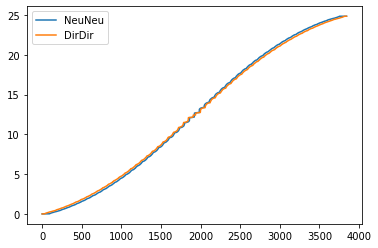

In [9]:
ax = plt.gca()
plt.plot(eigValsSort_NeuNeu, label = "NeuNeu")
plt.plot(eigValsSort_DirDir, label = "DirDir")
plt.legend()
plt.show()

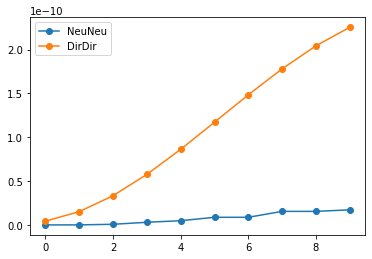

In [10]:
ax = plt.gca()
plt.plot(np.arange(10), eigValsSort_NeuNeu[:10], marker='o', label = "NeuNeu")
plt.plot(np.arange(10), eigValsSort_DirDir[:10], marker='o', label = "DirDir")
plt.legend()
plt.show()

In [11]:
np.set_printoptions(formatter={'float': '{:.30e}'.format})
print(eigValsSort_NeuNeu[0:10])
print(eigValsSort_DirDir[0:10])
np.set_printoptions()

[6.11953420e-15+0.00000000e+00j 4.73625917e-14+0.00000000e+00j
 7.30254941e-13+0.00000000e+00j 2.99828325e-12+0.00000000e+00j
 4.81850644e-12+0.00000000e+00j 8.70029156e-12-1.58383814e-12j
 8.70029156e-12+1.58383814e-12j 1.54497320e-11-6.67112151e-12j
 1.54497320e-11+6.67112151e-12j 1.72046400e-11-2.30970615e-12j]
[4.30206278e-12+0.j 1.51423752e-11+0.j 3.33363123e-11+0.j
 5.76495044e-11+0.j 8.62235251e-11+0.j 1.17154270e-10+0.j
 1.48394220e-10+0.j 1.78032528e-10+0.j 2.04279672e-10+0.j
 2.25455891e-10+0.j]


c:\Users\koich\anaconda3\lib\site-packages\matplotlib\contour.py:1454: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmax = float(z.max())
c:\Users\koich\anaconda3\lib\site-packages\matplotlib\contour.py:1455: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmin = float(z.min())
c:\Users\koich\anaconda3\lib\site-packages\numpy\ma\core.py:2825: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,


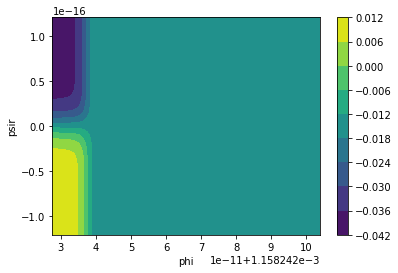

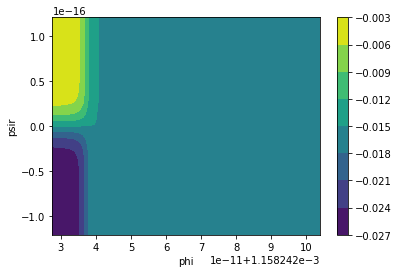

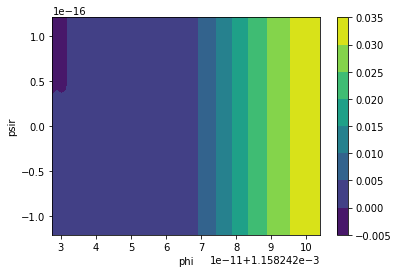

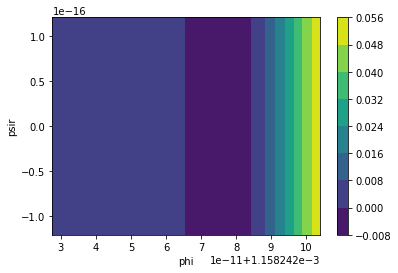

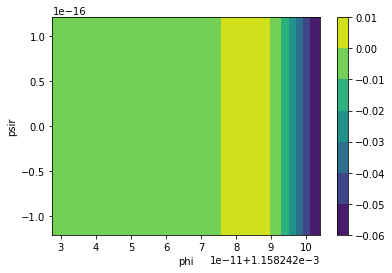

In [12]:
# 固有関数のプロット
customGrid_phi_woEnd = customGrid_phi[1:-1]
customGrid_psir_woEnd = customGrid_psir[1:-1]

for iEig in range(5):   
    fig, ax1 = plt.subplots(1)
    cntr1 = ax1.contourf(customGrid_phi_woEnd, customGrid_psir_woEnd, np.reshape(eigVecsSort_NeuNeu[iEig], (nGrid-2, nGrid-2)).T)
    fig.colorbar(cntr1, ax=ax1)
    ax1.set_xlabel("phi")
    ax1.set_ylabel("psir")
    plt.show()

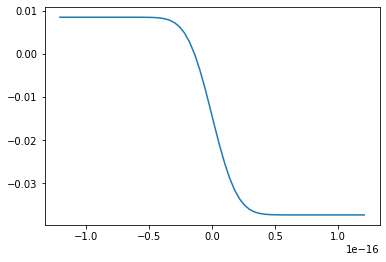

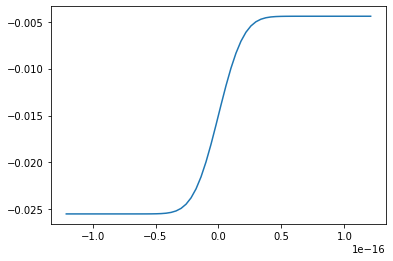

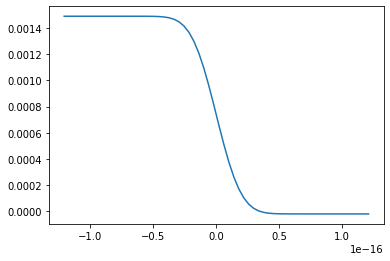

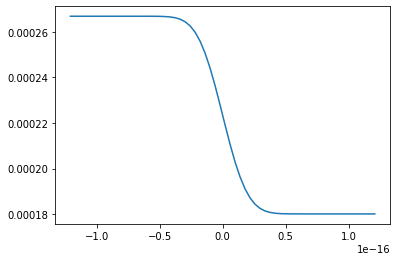

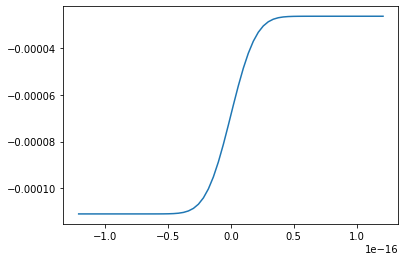

In [19]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_psir_woEnd, np.reshape(eigVecsSort_NeuNeu[iEig], (nGrid-2, nGrid-2))[0,:])
    plt.show()

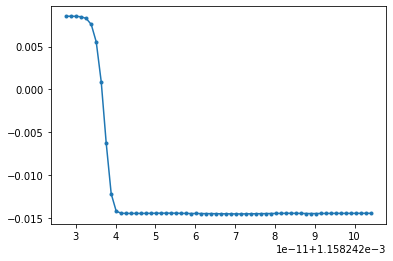

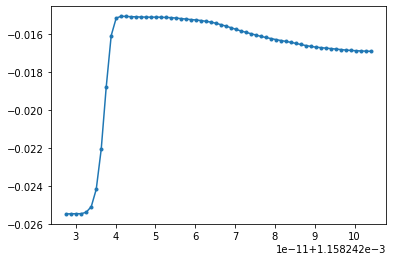

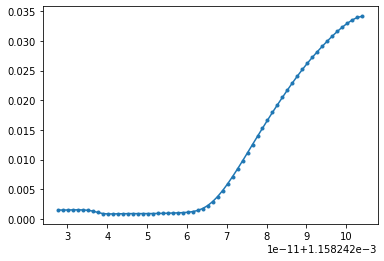

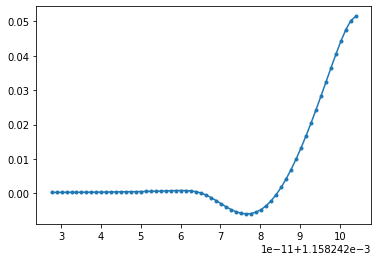

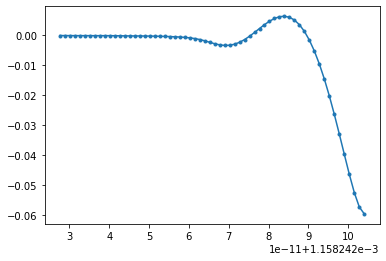

In [20]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_phi_woEnd, np.reshape(eigVecsSort_NeuNeu[iEig], (nGrid-2, nGrid-2))[:,15], marker=".")
    plt.show()

121 1 (-0.03734323303624567+0j)


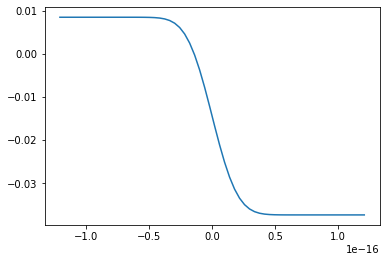

In [15]:
i = np.argmax(np.abs(eigVecsSort_NeuNeu[0]))
print(i, i // (nGrid-2), eigVecsSort_NeuNeu[0][i])

ax = plt.gca()
plt.plot(customGrid_psir_woEnd, np.reshape(eigVecsSort_NeuNeu[0], (nGrid-2, nGrid-2))[i // (nGrid-2),:])
plt.show()

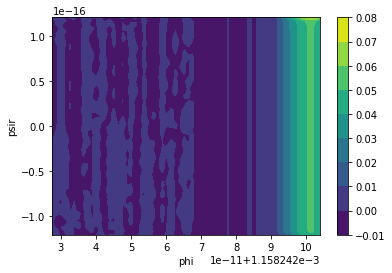

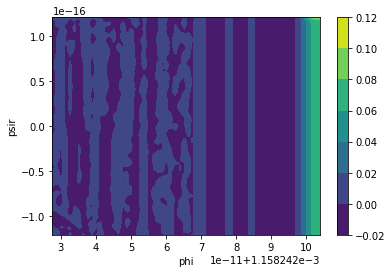

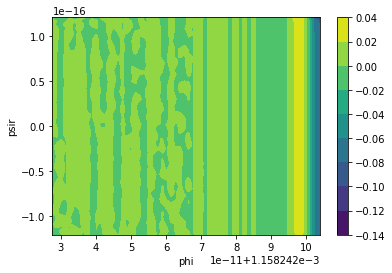

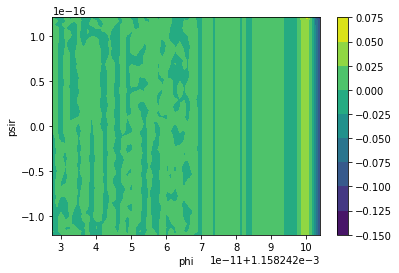

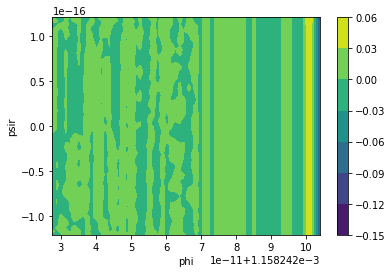

In [16]:
# 固有関数のプロット
for iEig in range(5):   
    fig, ax1 = plt.subplots(1)
    cntr1 = ax1.contourf(customGrid_phi_woEnd, customGrid_psir_woEnd, np.reshape(eigVecsSort_DirDir[iEig], (nGrid-2, nGrid-2)).T)
    fig.colorbar(cntr1, ax=ax1)
    ax1.set_xlabel("phi")
    ax1.set_ylabel("psir")
    plt.show()

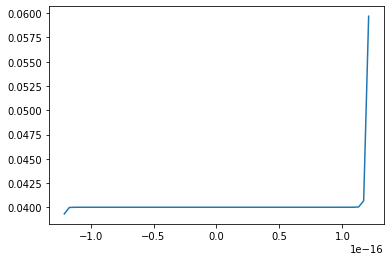

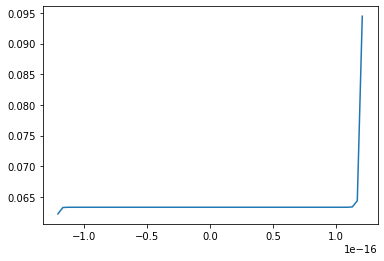

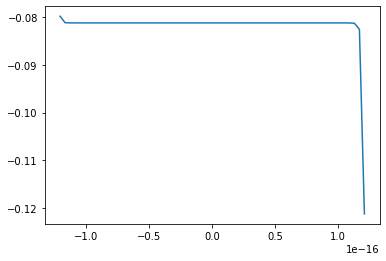

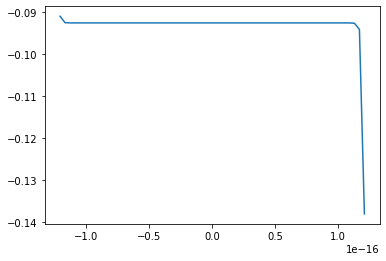

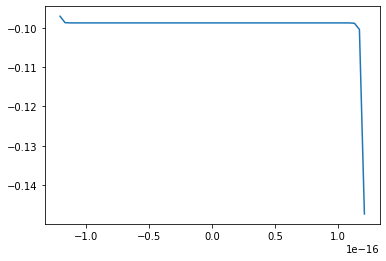

In [17]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_psir_woEnd, np.reshape(eigVecsSort_DirDir[iEig], (nGrid-2, nGrid-2))[-1,:])
    plt.show()

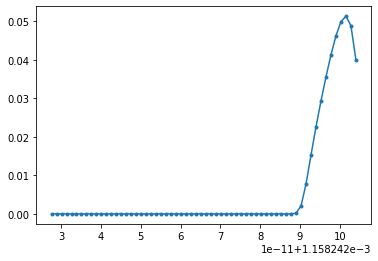

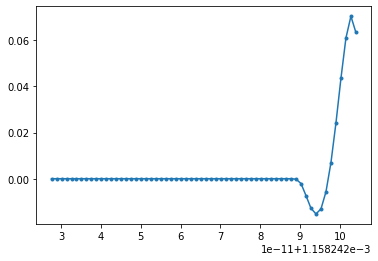

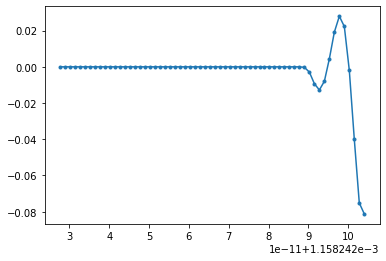

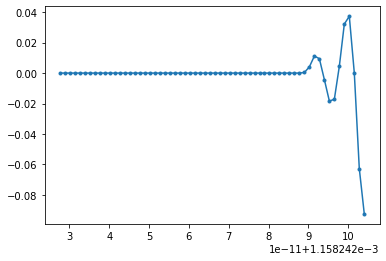

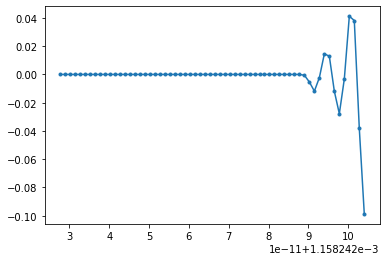

In [18]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_phi_woEnd, np.reshape(eigVecsSort_DirDir[iEig], (nGrid-2, nGrid-2))[:,30], marker=".")
    plt.show()

1.5327712741862801e-15


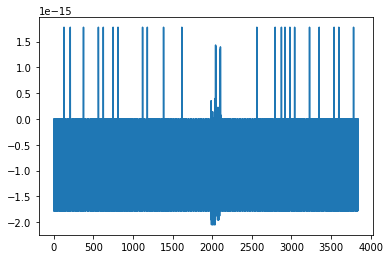

In [26]:
# NeuNeuは(1,...,1)を固有値ゼロの固有ベクトルに持つはずでは？
nGridTot = (nGrid - 2)**2
vec1 = np.repeat(1, nGridTot)

Lvec1 = fpFinDiff_NeuNeu @ vec1

ax = plt.gca()
plt.plot(Lvec1)

print(np.linalg.norm(Lvec1) / np.linalg.norm(vec1))

In [27]:
np.min(np.abs(eigVals_NeuNeu))

6.1195342032357105e-15

桁落ちとかで固有値が求まってないのかな...

いずれにせよ、全部の境界をノイマンにしちゃうと、全ての場所で値一定の関数が固有関数になっちゃって意味ない！

やはり、スローロールが破れるところまでとって、ディリクレを課さないと！